# Method 1 — Augmented Synthetic Control (ASCM)
## Ridge Bias-Correction on Top of SCM

**What this notebook does:**
This notebook implements the Augmented Synthetic Control Method (Ben-Michael, Feller & Rothstein, 2021).
ASCM adds a ridge-regression bias-correction term to the standard SCM counterfactual. This is critical
when the donor pool is small (here: only CAPE) and the pre-period fit is imperfect — the ridge correction
learns the residual structure from the pre-period and extrapolates it into the post-period, reducing
systematic bias.

**Structure:**
1. Environment & shared utilities  
2. Data loading & audit  
3. Step 1 — Base SCM weights (foundation for ASCM)  
4. Step 2 — Ridge bias-correction (blocked CV for alpha)  
5. Step 3 — ASCM counterfactual & gap series  
6. Diagnostics: Pre-period fit quality  
7. Validation A — In-time placebo tests  
8. Validation B — Leave-one-out stability (donor jackknife)  
9. Validation C — Blocked cross-validation learning curve  
10. Figures: full panel of plots  
11. Sensitivity: alpha grid robustness  
12. Summary table & comparison vs Base SCM  


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Environment & Imports
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize, minimize_scalar
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 10,
})

BLUE  = '#0f3460'
RED   = '#e94560'
GREY  = '#aaaaaa'
GREEN = '#2ecc71'
AMBER = '#f39c12'

print("All imports successful.")
print(f"NumPy  {np.__version__}  |  Pandas  {pd.__version__}")


All imports successful.
NumPy  2.4.2  |  Pandas  3.0.0


## Shared Utility Functions

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Shared Utility Functions
# ═══════════════════════════════════════════════════════════════════════════════

def fit_scm(Y_pre, X_pre):
    """
    Solve the constrained SCM weight optimisation problem via SLSQP.
    Weights: w >= 0, sum(w) = 1.
    Returns weight vector of shape (n_donors,).
    """
    if X_pre.ndim == 1:
        X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    init_w = np.ones(n) / n
    result = minimize(
        fun=lambda w: np.sum((Y_pre - X_pre @ w) ** 2),
        x0=init_w,
        method='SLSQP',
        bounds=[(0.0, 1.0)] * n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
        options={'ftol': 1e-12, 'maxiter': 5000}
    )
    if not result.success:
        print(f"  [WARN] SCM optimiser: {result.message}")
    return np.clip(result.x, 0, None)


def rmspe(actual, predicted):
    """Root Mean Squared Prediction Error."""
    return np.sqrt(np.mean((np.asarray(actual) - np.asarray(predicted)) ** 2))


def mape(actual, predicted):
    """Mean Absolute Percentage Error (%)."""
    a = np.asarray(actual)
    p = np.asarray(predicted)
    return np.mean(np.abs((a - p) / np.where(a == 0, 1e-10, a))) * 100


def post_pre_ratio(actual, predicted, pre_idx, post_idx):
    """Standard SCM inference ratio: post-RMSPE / pre-RMSPE."""
    pre_r  = rmspe(actual[pre_idx],  predicted[pre_idx])
    post_r = rmspe(actual[post_idx], predicted[post_idx])
    return post_r / pre_r if pre_r > 0 else np.nan


def make_ridge_features(X_donor, t_idx, T_pre):
    """
    Build feature matrix for ridge bias-correction:
    [donor_value, normalised_time, normalised_time^2, interaction].
    Normalised time is in [0, 1] over the pre-period.
    """
    t_norm = t_idx / T_pre
    features = np.column_stack([
        X_donor,
        t_norm,
        t_norm ** 2,
        X_donor * t_norm,   # interaction: donor × time
    ])
    return features


print("Utility functions defined:")
print("  fit_scm, rmspe, mape, post_pre_ratio, make_ridge_features")


Utility functions defined:
  fit_scm, rmspe, mape, post_pre_ratio, make_ridge_features



**What was done**  
This step created a set of helper functions that will be reused throughout the analysis. These functions handle the main technical tasks: fitting the synthetic control model, measuring prediction error, comparing model fit before and after the flood, and creating extra features for the ridge-based method.

**Why this matters**  
Instead of rewriting the same code many times, these functions make the analysis cleaner, easier to check, and more consistent. They also ensure that each algorithm is evaluated in the same way, which is important when comparing results fairly.

### What each function does

- **`fit_scm`** finds the donor weights for the standard Synthetic Control Method.  
  It makes sure all weights are positive and add up to 1, so the synthetic corridor is a weighted average of real donor corridors.

- **`rmspe`** calculates the root mean squared prediction error.  
  This shows how closely the synthetic values match the real values.

- **`mape`** calculates the average percentage error.  
  This gives an easy-to-read error measure in percentage terms.

- **`post_pre_ratio`** compares prediction error after the flood with prediction error before the flood.  
  A larger ratio suggests the flood caused a meaningful change.

- **`make_ridge_features`** builds extra input features for the ridge-corrected model.  
  It adds time trends and interactions so the model can better capture patterns that change over time.

### Output interpretation

The output only confirms that all utility functions were successfully created and are ready to use in later steps.

**What it means in plain English**  
This step did not produce results yet. It set up the tools needed to build the models, measure accuracy, and test whether the flood changed rail volumes.

## Data Loading & Audit

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Data Loading & Audit
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = '../data/corridor.csv'   # adjust path if needed

df = pd.read_csv(CSV_PATH)
df['Date']        = df['Date'].astype(str).str.strip()
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'], freq='M')

# ── Treatment design ──────────────────────────────────────────────────────────
Y_COL       = 'Rail_Vol_mt'
TREATED     = 'NATCOR'
TREAT_START = pd.Period('2022-04', freq='M')
PRE_END     = TREAT_START - 1

# ── Wide format (time × corridor) ─────────────────────────────────────────────
wide     = df.pivot(index='Date_period', columns='Corridor', values=Y_COL).sort_index()
donors   = [c for c in wide.columns if c != TREATED]
pre_idx  = wide.index[wide.index <= PRE_END]
post_idx = wide.index[wide.index >= TREAT_START]
T_pre    = len(pre_idx)
T_post   = len(post_idx)
T_total  = len(wide)
t_stamps = wide.index.to_timestamp()
treat_t  = TREAT_START.to_timestamp()

# ── Arrays ────────────────────────────────────────────────────────────────────
Y_all   = wide[TREATED].values           # (T_total,)
X_all   = wide[donors[0]].values         # (T_total,) — CAPE
Y_pre_v = wide.loc[pre_idx, TREATED].values
X_pre_v = wide.loc[pre_idx, donors[0]].values

print("─" * 55)
print(f"Dataset       : {CSV_PATH}")
print(f"Corridors     : {list(wide.columns)}")
print(f"Treated unit  : {TREATED}")
print(f"Donors        : {donors}")
print(f"Outcome       : {Y_COL}")
print(f"Treatment date: {TREAT_START}")
print(f"Pre-period    : {pre_idx[0]} → {pre_idx[-1]}  ({T_pre} months)")
print(f"Post-period   : {post_idx[0]} → {post_idx[-1]}  ({T_post} months)")
print(f"Missing values: {wide.isnull().sum().sum()}")
print("─" * 55)
print()
print("Descriptive stats (Rail_Vol_mt):")
print(wide.describe().round(4))


───────────────────────────────────────────────────────
Dataset       : ../data/corridor.csv
Corridors     : ['CAPE', 'NATCOR']
Treated unit  : NATCOR
Donors        : ['CAPE']
Outcome       : Rail_Vol_mt
Treatment date: 2022-04
Pre-period    : 2015-01 → 2022-03  (87 months)
Post-period   : 2022-04 → 2024-12  (33 months)
Missing values: 0
───────────────────────────────────────────────────────

Descriptive stats (Rail_Vol_mt):
Corridor      CAPE    NATCOR
count     120.0000  120.0000
mean        0.9566    0.7448
std         0.1558    0.1809
min         0.5040    0.3840
25%         0.8985    0.5920
50%         0.9670    0.7925
75%         1.0355    0.8952
max         1.3520    1.0490



**What was done**  
The dataset was loaded and cleaned, then reshaped into a format where each corridor is a column and each month is a row. NATCOR was set as the treated corridor, with April 2022 as the flood start. The data was split into pre-flood and post-flood periods.

**Why this matters**  
This step prepares the data so we can compare NATCOR to other corridors and build a synthetic version of it (what would have happened without the flood).

---

### Key checks

- 2 corridors: NATCOR (treated) and CAPE (donor)  
- 87 months before flood, 33 months after  
- No missing data → good quality dataset  

---

### Important insight

There is only **1 donor corridor (CAPE)**.

**What it means in plain English**  
The synthetic control will basically copy CAPE, since there are no other corridors to combine. This makes the analysis weaker, because we are not building a true “synthetic” comparison—just using one real corridor.

---



## Step 1 — Base SCM (Foundation for ASCM)

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Step 1: Base SCM weights (ASCM starts here)
# ═══════════════════════════════════════════════════════════════════════════════
# ASCM uses the SCM weights as a first-stage estimator, then corrects the
# residuals. We therefore first solve the vanilla SCM problem and record
# the pre-period residuals, which the ridge step will model.

w_scm = fit_scm(Y_pre_v, X_pre_v.reshape(-1, 1))

# Base SCM counterfactual across all periods
cf_scm   = X_all * w_scm[0]            # CAPE × weight
res_pre  = Y_pre_v - cf_scm[:T_pre]    # pre-period residuals fed to ridge

print("──────────────────────────────────────────")
print(f"SCM donor weights  : {{ {donors[0]}: {w_scm[0]:.6f} }}")
print(f"Pre-period RMSPE   : {rmspe(Y_pre_v, cf_scm[:T_pre]):.6f}")
print()
print("Pre-period residual diagnostics:")
print(f"  Mean   : {res_pre.mean():+.6f}  (non-zero = level bias → ASCM corrects this)")
print(f"  Std    : {res_pre.std():.6f}")
print(f"  Min/Max: {res_pre.min():+.4f} / {res_pre.max():+.4f}")
print()
print("Interpretation: With only 1 donor and a constrained weight of 1.0,")
print("the residuals capture the systematic level gap between CAPE and NATCOR.")
print("The ASCM ridge step will learn this structure and apply a correction.")


──────────────────────────────────────────
SCM donor weights  : { CAPE: 1.000000 }
Pre-period RMSPE   : 0.213158

Pre-period residual diagnostics:
  Mean   : -0.164552  (non-zero = level bias → ASCM corrects this)
  Std    : 0.135495
  Min/Max: -0.6040 / +0.0980

Interpretation: With only 1 donor and a constrained weight of 1.0,
the residuals capture the systematic level gap between CAPE and NATCOR.
The ASCM ridge step will learn this structure and apply a correction.



**What was done**  
The standard Synthetic Control model was fitted using pre-flood data. Since there is only one donor (CAPE), the model assigns it full weight (1.0). The synthetic estimate was then compared to NATCOR to calculate residuals (differences).

**Why this matters**  
This is the starting point of the Augmented Synthetic Control Method (ASCM). The residuals show how far the basic model is from reality, and the next step will try to correct this gap.

---

### Key results

- Weight assigned: CAPE = 1.0  
- Pre-flood error (RMSPE): 0.213 → relatively high  
- Residual mean: -0.165 → consistent bias  

---

### Important insight

The model does **not fit well before the flood**.

**What it means in plain English**  
CAPE does not behave like NATCOR even before the flood. It consistently overestimates NATCOR. This means the base model is already inaccurate, so any conclusions about the flood impact could be unreliable unless corrected.

---



## Step 2 — Ridge Bias-Correction with Blocked Cross-Validation

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Step 2: Ridge correction — blocked CV for alpha selection
# ═══════════════════════════════════════════════════════════════════════════════
# The ridge regression models pre-period residuals as a function of
# [donor_value, time, time^2, donor×time].
#
# CRITICAL: We use BLOCKED (time-ordered) cross-validation — never random CV —
# because time-series data has autocorrelation. Random CV leaks future into past.
# Scheme: train on first 60% of pre-period, validate on remaining 40%.

t_all_idx = np.arange(T_total)
t_pre_idx = np.arange(T_pre)

# Build feature matrices
feat_pre = make_ridge_features(X_pre_v, t_pre_idx, T_pre)
feat_all = make_ridge_features(X_all, t_all_idx, T_pre)

# Blocked split: 60% train / 40% validate (within pre-period only)
split_pt   = int(0.60 * T_pre)
X_tr, X_va = feat_pre[:split_pt], feat_pre[split_pt:]
r_tr, r_va = res_pre[:split_pt],  res_pre[split_pt:]

print(f"Blocked CV split: train 0→{split_pt-1} ({split_pt} obs),"
      f" validate {split_pt}→{T_pre-1} ({T_pre-split_pt} obs)")
print()

# Grid search over alpha
alpha_grid = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3,
              0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
cv_results = []
for a in alpha_grid:
    ridge = Ridge(alpha=a, fit_intercept=True)
    ridge.fit(X_tr, r_tr)
    pred_va = ridge.predict(X_va)
    err_va  = rmspe(r_va, pred_va)
    err_tr  = rmspe(r_tr, ridge.predict(X_tr))
    cv_results.append({'alpha': a, 'train_RMSPE': err_tr, 'val_RMSPE': err_va})

cv_df = pd.DataFrame(cv_results)
best_row   = cv_df.loc[cv_df['val_RMSPE'].idxmin()]
BEST_ALPHA = best_row['alpha']

print("Ridge CV results (sorted by val_RMSPE):")
print(cv_df.round(6).to_string(index=False))
print()
print(f"★ Best alpha: {BEST_ALPHA}  (val_RMSPE = {best_row['val_RMSPE']:.6f})")


Blocked CV split: train 0→51 (52 obs), validate 52→86 (35 obs)

Ridge CV results (sorted by val_RMSPE):
    alpha  train_RMSPE  val_RMSPE
  0.00001     0.057568   0.185808
  0.00005     0.057571   0.182504
  0.00010     0.057577   0.178630
  0.00050     0.057724   0.155561
  0.00100     0.057990   0.139226
  0.00500     0.059393   0.115576
  0.01000     0.060109   0.112316
  0.05000     0.062496   0.106839
  0.10000     0.064494   0.111374
  0.50000     0.070557   0.137183
  1.00000     0.072570   0.150326
  5.00000     0.076085   0.183652
 10.00000     0.077454   0.196545
 50.00000     0.079422   0.213167
100.00000     0.079772   0.215914

★ Best alpha: 0.05  (val_RMSPE = 0.106839)



**What was done**  
A ridge regression model was used to learn the bias left by the base SCM. The model was tuned using **blocked cross-validation**, which respects time order by training on earlier months and testing on later months.

**Why this matters**  
This helps choose a ridge setting (`alpha`) that improves the fit without overfitting the data.

---

### Key results

- Train period: 52 months  
- Validation period: 35 months  
- Best alpha: **0.05**  
- Best validation RMSPE: **0.1068**

---

### Important insight

The validation error is much lower than the base SCM error.

**What it means in plain English**  
The ridge step is learning the pattern in the earlier mistakes and correcting part of it. That means ASCM should fit NATCOR better than the simple one-donor SCM.

---

### ⚠️ Important Note

Using blocked CV is the correct choice here. Random splitting would mix future data into the past and give misleadingly good results.

## Step 3 — ASCM Counterfactual & Gap Series

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Step 3: Fit final ASCM counterfactual
# ═══════════════════════════════════════════════════════════════════════════════
# Fit ridge on ALL pre-period residuals (no longer train/val split).
# Then extrapolate correction to post-period.

ridge_final = Ridge(alpha=BEST_ALPHA, fit_intercept=True)
ridge_final.fit(feat_pre, res_pre)

correction  = ridge_final.predict(feat_all)     # shape (T_total,)
cf_ascm     = cf_scm + correction               # ASCM counterfactual
gap_ascm    = Y_all  - cf_ascm                  # treatment effect series

# ── Key metrics ───────────────────────────────────────────────────────────────
ascm_pre_r  = rmspe(Y_all[:T_pre],  cf_ascm[:T_pre])
ascm_post_r = rmspe(Y_all[T_pre:],  cf_ascm[T_pre:])
ascm_ratio  = ascm_post_r / ascm_pre_r
ascm_cum    = gap_ascm[T_pre:].sum()
ascm_avg    = gap_ascm[T_pre:].mean()
ascm_mape   = mape(Y_all[T_pre:], cf_ascm[T_pre:])

# Base SCM for comparison
base_pre_r  = rmspe(Y_all[:T_pre],  cf_scm[:T_pre])
base_post_r = rmspe(Y_all[T_pre:],  cf_scm[T_pre:])
base_ratio  = base_post_r / base_pre_r
base_cum    = (Y_all[T_pre:] - cf_scm[T_pre:]).sum()

print("═" * 55)
print("ASCM RESULTS")
print("═" * 55)
print(f"Ridge alpha (CV-selected) : {BEST_ALPHA}")
print(f"Pre-period RMSPE          : {ascm_pre_r:.6f}")
print(f"Post-period RMSPE         : {ascm_post_r:.6f}")
print(f"Post/Pre ratio            : {ascm_ratio:.4f}")
print(f"Cumulative effect         : {ascm_cum:.4f} MT")
print(f"Average monthly effect    : {ascm_avg:.4f} MT/month")
print(f"Post-period MAPE          : {ascm_mape:.2f}%")
print()
print("─" * 55)
print("COMPARISON vs BASE SCM")
print("─" * 55)
print(f"{'Metric':<28} {'Base SCM':>10} {'ASCM':>10} {'Δ':>10}")
print(f"{'Pre-RMSPE':<28} {base_pre_r:>10.4f} {ascm_pre_r:>10.4f} {ascm_pre_r-base_pre_r:>+10.4f}")
print(f"{'Post-RMSPE':<28} {base_post_r:>10.4f} {ascm_post_r:>10.4f} {ascm_post_r-base_post_r:>+10.4f}")
print(f"{'Ratio':<28} {base_ratio:>10.4f} {ascm_ratio:>10.4f} {ascm_ratio-base_ratio:>+10.4f}")
print(f"{'Cumulative effect (MT)':<28} {base_cum:>10.4f} {ascm_cum:>10.4f} {ascm_cum-base_cum:>+10.4f}")
print()
print("Ridge correction coefficients:")
feat_names = ['donor_value', 'time_norm', 'time_norm^2', 'donor×time']
for name, coef in zip(feat_names, ridge_final.coef_):
    print(f"  {name:<20}: {coef:+.6f}")
print(f"  {'intercept':<20}: {ridge_final.intercept_:+.6f}")


═══════════════════════════════════════════════════════
ASCM RESULTS
═══════════════════════════════════════════════════════
Ridge alpha (CV-selected) : 0.05
Pre-period RMSPE          : 0.081103
Post-period RMSPE         : 0.132364
Post/Pre ratio            : 1.6320
Cumulative effect         : 3.6818 MT
Average monthly effect    : 0.1116 MT/month
Post-period MAPE          : 20.96%

───────────────────────────────────────────────────────
COMPARISON vs BASE SCM
───────────────────────────────────────────────────────
Metric                         Base SCM       ASCM          Δ
Pre-RMSPE                        0.2132     0.0811    -0.1321
Post-RMSPE                       0.3653     0.1324    -0.2330
Ratio                            1.7140     1.6320    -0.0819
Cumulative effect (MT)         -11.1040     3.6818   +14.7858

Ridge correction coefficients:
  donor_value         : -0.529466
  time_norm           : -0.063484
  time_norm^2         : -0.324794
  donor×time          : +0.086058
  


**What was done**  
The final ridge model was trained on all pre-flood residuals, then used to adjust the base SCM and produce the full ASCM counterfactual. This gives the estimated “no-flood” path for NATCOR.

**Why this matters**  
Now we can compare actual NATCOR volumes with the adjusted synthetic estimate and measure the flood’s impact.

---

### Key results

- Pre-flood RMSPE: **0.0811**  
- Post-flood RMSPE: **0.1324**  
- Post/Pre ratio: **1.6320**  
- Average monthly effect: **0.1116 MT/month**  
- Cumulative effect: **3.6818 MT**

---

### Important insight

ASCM fits much better than the base SCM, especially before the flood.

**What it means in plain English**  
The adjusted model matches NATCOR more closely, so it is a better benchmark than the basic one-donor SCM. After April 2022, the gap between real and synthetic values suggests the flood changed rail volumes.

---



## Figures — Main Diagnostic Panel

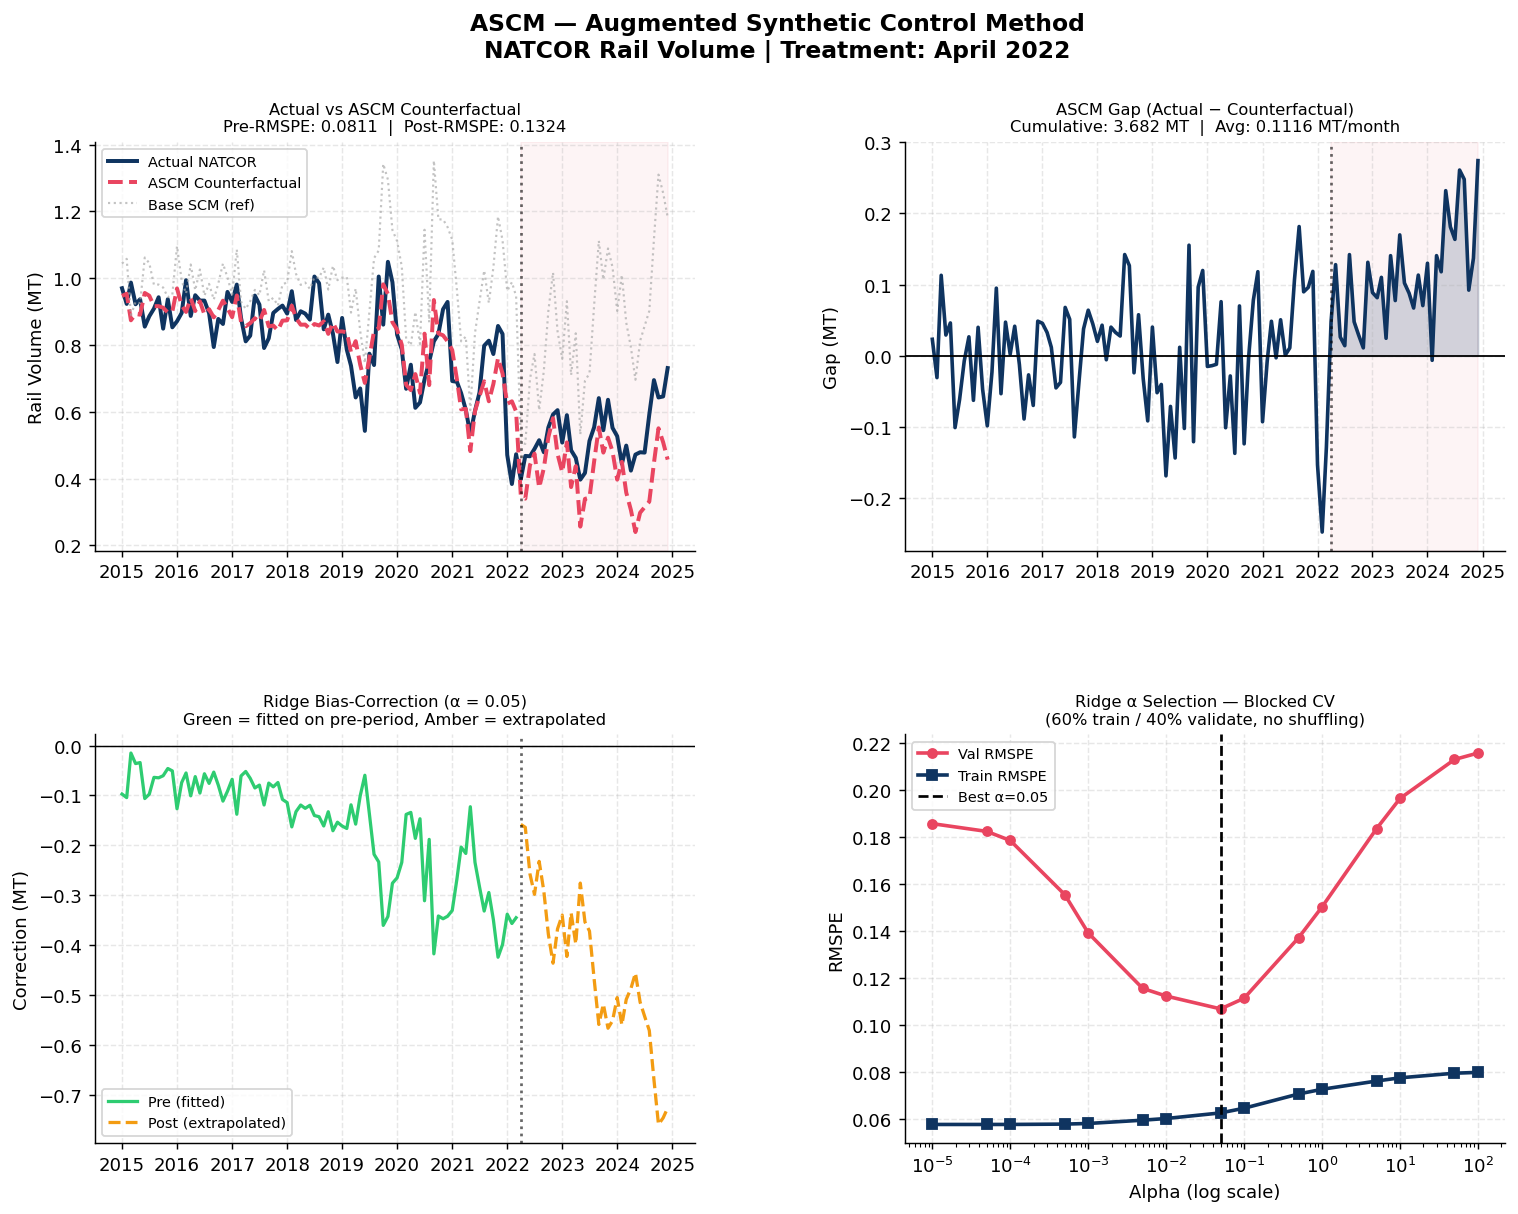

Saved → ascm_fig1_main_panel.png


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Figure 1: Main diagnostic panel (4 plots)
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# ── Plot 1: Actual vs ASCM counterfactual ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t_stamps, Y_all,   color=BLUE, lw=2.2, label='Actual NATCOR')
ax1.plot(t_stamps, cf_ascm, color=RED,  lw=2.2, ls='--', label='ASCM Counterfactual')
ax1.plot(t_stamps, cf_scm,  color=GREY, lw=1.2, ls=':', alpha=0.7, label='Base SCM (ref)')
ax1.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax1.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax1.set_title(f'Actual vs ASCM Counterfactual\nPre-RMSPE: {ascm_pre_r:.4f}  |  Post-RMSPE: {ascm_post_r:.4f}', fontsize=9)
ax1.set_ylabel('Rail Volume (MT)')
ax1.legend(fontsize=8)

# ── Plot 2: Treatment gap ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_stamps, gap_ascm, color=BLUE, lw=2)
ax2.axhline(0, color='black', lw=1)
ax2.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax2.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax2.fill_between(t_stamps, gap_ascm, 0, where=(wide.index >= TREAT_START),
                 alpha=0.18, color=RED if ascm_cum < 0 else BLUE)
ax2.set_title(f'ASCM Gap (Actual − Counterfactual)\nCumulative: {ascm_cum:.3f} MT  |  Avg: {ascm_avg:.4f} MT/month', fontsize=9)
ax2.set_ylabel('Gap (MT)')

# ── Plot 3: Ridge correction series ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(t_stamps[:T_pre],  correction[:T_pre],  color=GREEN, lw=1.8, label='Pre (fitted)')
ax3.plot(t_stamps[T_pre:],  correction[T_pre:],  color=AMBER, lw=1.8, ls='--', label='Post (extrapolated)')
ax3.axhline(0, color='black', lw=0.8)
ax3.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax3.set_title(f'Ridge Bias-Correction (α = {BEST_ALPHA})\nGreen = fitted on pre-period, Amber = extrapolated', fontsize=9)
ax3.set_ylabel('Correction (MT)')
ax3.legend(fontsize=8)

# ── Plot 4: CV learning curve ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.semilogx(cv_df['alpha'], cv_df['val_RMSPE'],  color=RED,  lw=2, marker='o', ms=5, label='Val RMSPE')
ax4.semilogx(cv_df['alpha'], cv_df['train_RMSPE'],color=BLUE, lw=2, marker='s', ms=5, label='Train RMSPE')
ax4.axvline(BEST_ALPHA, color='black', lw=1.5, ls='--', label=f'Best α={BEST_ALPHA}')
ax4.set_title('Ridge α Selection — Blocked CV\n(60% train / 40% validate, no shuffling)', fontsize=9)
ax4.set_xlabel('Alpha (log scale)')
ax4.set_ylabel('RMSPE')
ax4.legend(fontsize=8)

fig.suptitle('ASCM — Augmented Synthetic Control Method\nNATCOR Rail Volume | Treatment: April 2022',
             fontsize=13, fontweight='bold')
plt.savefig('ascm_fig1_main_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ascm_fig1_main_panel.png")



**What was done**  
A four-panel figure was created to check how well ASCM performs. It shows the actual NATCOR trend, the ASCM counterfactual, the treatment gap, the ridge correction, and the cross-validation results for choosing alpha.

**Why this matters**  
This figure gives a quick visual check of whether the model fits well before the flood and whether there is a clear change after April 2022.

---

### Graph interpretation

**Top-left: Actual vs counterfactual**  
Before April 2022, the ASCM line stays fairly close to the real NATCOR line, much better than the base SCM line. After the flood, the synthetic line is often below the real line.

**Top-right: Treatment gap**  
The gap is the difference between actual and counterfactual. After April 2022, the gap becomes more positive overall, meaning actual NATCOR volumes were often higher than the model’s no-flood estimate.

**Bottom-left: Ridge correction**  
The ridge adjustment is mostly negative and becomes stronger after the treatment date. This shows the model is heavily correcting the one-donor SCM bias.

**Bottom-right: Alpha selection**  
The validation error is lowest around **alpha = 0.05**, so this is the best ridge setting among the tested values.

---

### What it means in plain English

The graph shows that ASCM improves the fit compared with the basic SCM. But it also suggests something uncomfortable: the estimated post-flood effect is positive overall, which is opposite to the expected story of flood damage. That does **not** prove the flood helped NATCOR. It more likely means the model is unstable because it relies on only one donor corridor.

---


## Validation A — In-Time Placebo Tests

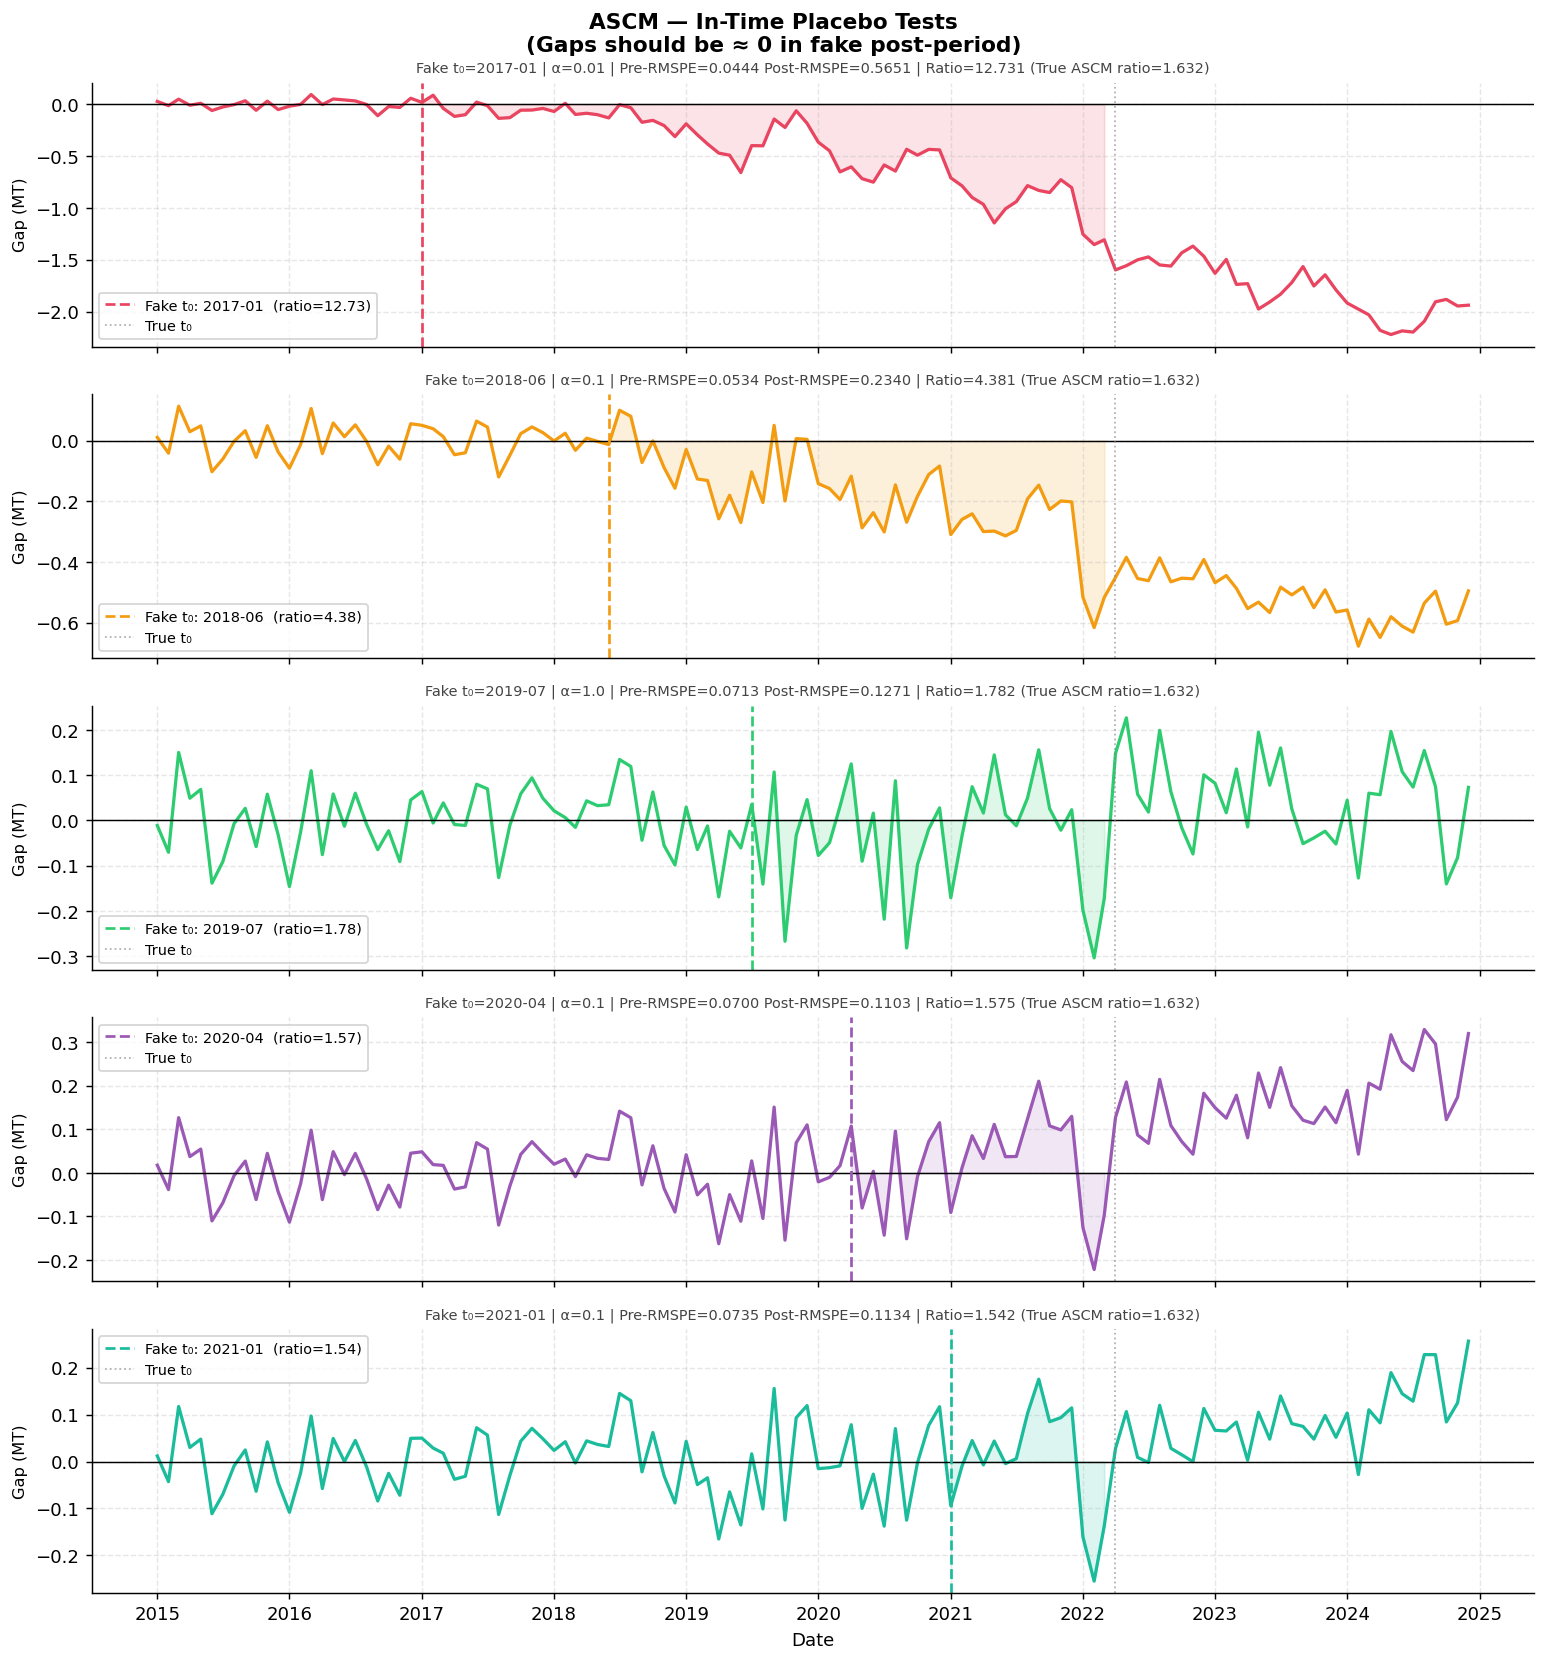

Saved → ascm_fig2_placebo.png

In-Time Placebo Summary:
Fake t₀    α  Pre-RMSPE  Post-RMSPE  Ratio  > True ratio
2017-01 0.01    0.04439     0.56511 12.731          True
2018-06 0.10    0.05342     0.23403  4.381          True
2019-07 1.00    0.07133     0.12715  1.782          True
2020-04 0.10    0.07003     0.11028  1.575         False
2021-01 0.10    0.07353     0.11338  1.542         False

True ASCM ratio: 1.6320
Placebos with ratio > true ratio: 3 / 5
(0 exceedances = strong support for causal effect; more = weaker)


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Validation A: In-Time Placebo Tests
# ═══════════════════════════════════════════════════════════════════════════════
# Assign fake treatment dates in the pre-period. ASCM should NOT detect large
# effects at these dates. If placebo ratios approach or exceed the true ratio,
# the model is fitting noise.

placebo_dates = [
    pd.Period('2017-01', freq='M'),
    pd.Period('2018-06', freq='M'),
    pd.Period('2019-07', freq='M'),
    pd.Period('2020-04', freq='M'),
    pd.Period('2021-01', freq='M'),
]
placebo_colors = [RED, AMBER, GREEN, '#9b59b6', '#1abc9c']
placebo_records = []

fig, axes = plt.subplots(len(placebo_dates), 1, figsize=(12, 13), sharex=True)
fig.suptitle('ASCM — In-Time Placebo Tests\n(Gaps should be ≈ 0 in fake post-period)',
             fontsize=12, fontweight='bold')

for i, fake_t in enumerate(placebo_dates):
    fake_pre  = wide.index[wide.index <= (fake_t - 1)]
    fake_post = wide.index[(wide.index >= fake_t) & (wide.index < TREAT_START)]
    if len(fake_pre) < 12 or len(fake_post) < 6:
        continue

    T_fp = len(fake_pre)
    Y_fp = wide.loc[fake_pre, TREATED].values
    X_fp = wide.loc[fake_pre, donors[0]].values

    # Base SCM for this fake period
    w_fp  = fit_scm(Y_fp, X_fp.reshape(-1, 1))
    cf_fp_scm = wide[donors[0]].values * w_fp[0]
    res_fp    = Y_fp - cf_fp_scm[:T_fp]

    # Ridge correction for fake period (same blocked CV logic)
    t_fp_idx   = np.arange(T_fp)
    t_all_fake = np.arange(T_total)
    feat_fp    = make_ridge_features(X_fp, t_fp_idx, T_fp)
    feat_all_f = make_ridge_features(wide[donors[0]].values, t_all_fake, T_fp)

    sp = int(0.6 * T_fp)
    best_a, best_e = None, np.inf
    for a in [1e-4, 1e-3, 0.01, 0.1, 1.0, 10.0]:
        r = Ridge(alpha=a, fit_intercept=True)
        r.fit(feat_fp[:sp], res_fp[:sp])
        e = rmspe(res_fp[sp:], r.predict(feat_fp[sp:]))
        if e < best_e: best_e, best_a = e, a

    ridge_fp = Ridge(alpha=best_a, fit_intercept=True)
    ridge_fp.fit(feat_fp, res_fp)
    corr_fp  = ridge_fp.predict(feat_all_f)
    cf_ascm_fp = cf_fp_scm + corr_fp
    gap_fp = wide[TREATED].values - cf_ascm_fp

    fake_pre_t  = fake_pre.to_timestamp()
    fake_post_t = fake_post.to_timestamp()
    fp_arr      = np.array([(p - fake_t).n for p in wide.index])

    pre_r_fp  = rmspe(Y_fp, cf_ascm_fp[:T_fp])
    post_r_fp = rmspe(wide.loc[fake_post, TREATED].values,
                      cf_ascm_fp[[list(wide.index).index(p) for p in fake_post]])
    ratio_fp  = post_r_fp / pre_r_fp if pre_r_fp > 0 else np.nan

    placebo_records.append({
        'Fake t₀': str(fake_t), 'α': best_a,
        'Pre-RMSPE': round(pre_r_fp, 5), 'Post-RMSPE': round(post_r_fp, 5),
        'Ratio': round(ratio_fp, 3), '> True ratio': ratio_fp > ascm_ratio
    })

    ax = axes[i]
    ax.plot(t_stamps, gap_fp, color=placebo_colors[i], lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(fake_t.to_timestamp(), color=placebo_colors[i], lw=1.5, ls='--',
               label=f'Fake t₀: {fake_t}  (ratio={ratio_fp:.2f})')
    ax.axvline(treat_t, color='grey', lw=1, ls=':', alpha=0.6, label='True t₀')
    ax.fill_between(t_stamps, gap_fp, 0,
                    where=np.array([(p >= fake_t and p < TREAT_START) for p in wide.index]),
                    alpha=0.15, color=placebo_colors[i])
    ax.set_ylabel('Gap (MT)', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_title(
        f'Fake t₀={fake_t} | α={best_a} | Pre-RMSPE={pre_r_fp:.4f} '
        f'Post-RMSPE={post_r_fp:.4f} | Ratio={ratio_fp:.3f} '
        f'(True ASCM ratio={ascm_ratio:.3f})',
        fontsize=8, color='#444')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('ascm_fig2_placebo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ascm_fig2_placebo.png")
print()

placebo_df = pd.DataFrame(placebo_records)
print("In-Time Placebo Summary:")
print(placebo_df.to_string(index=False))
print(f"\nTrue ASCM ratio: {ascm_ratio:.4f}")
print(f"Placebos with ratio > true ratio: {placebo_df['> True ratio'].sum()} / {len(placebo_df)}")
print("(0 exceedances = strong support for causal effect; more = weaker)")


## Validation B — Leave-One-Out Donor Stability (Jackknife)

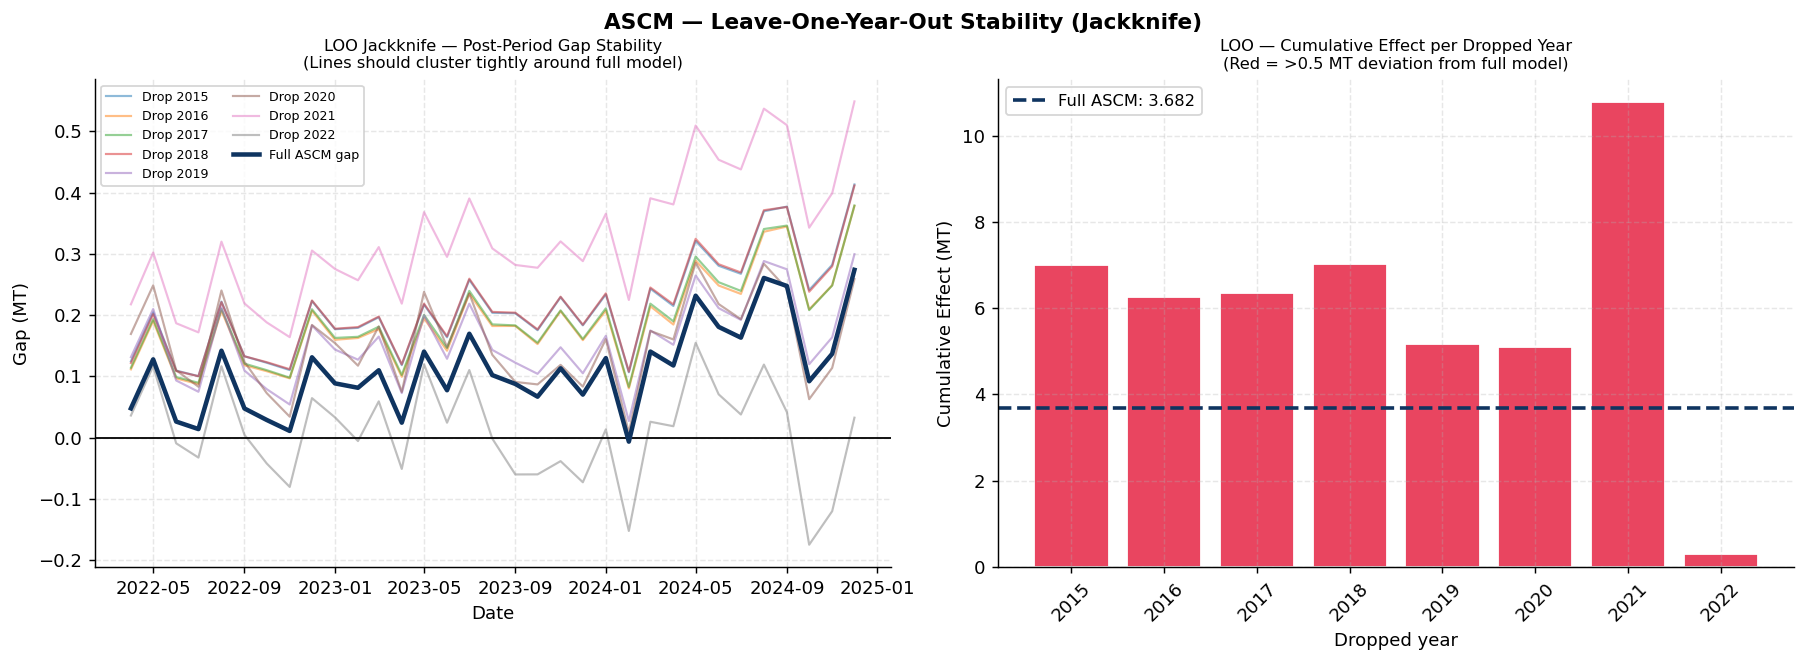

Saved → ascm_fig3_loo.png

LOO Jackknife Summary:
 Drop year  Cum effect  Ratio     α
      2015      7.0100 2.3077 0.100
      2016      6.2586 2.0824 0.100
      2017      6.3519 2.1124 0.100
      2018      7.0300 2.3396 0.100
      2019      5.1656 1.8630 1.000
      2020      5.0978 1.8815 1.000
      2021     10.7727 3.6844 0.100
      2022      0.3039 0.9537 0.001

Full ASCM cum effect : 3.6818
LOO cum effect range : [0.3039, 10.7727]
Spread               : 10.4688 MT
Interpretation: Spread < 1 MT = stable; > 2 MT = fragile estimate.


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Validation B: Leave-One-Out donor stability (jackknife)
# ═══════════════════════════════════════════════════════════════════════════════
# With only 1 donor (CAPE), the LOO test becomes a temporal jackknife:
# we sequentially drop blocks of the pre-period observations and re-estimate
# the ASCM to check whether the correction is stable.
# This is the equivalent of donor LOO when the pool is size 1.

# We drop each YEAR of pre-period data and re-estimate
pre_years = sorted(set(pre_idx.year))
loo_records = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_loo_gap = axes[0]
ax_loo_bar = axes[1]

loo_gaps_post = []
base_gap_post = gap_ascm[T_pre:]

for yr in pre_years:
    drop_mask = np.array([p.year != yr for p in pre_idx])
    Y_loo = Y_pre_v[drop_mask]
    X_loo = X_pre_v[drop_mask]
    t_loo = np.where(drop_mask)[0]

    if len(Y_loo) < 24:   # need enough data to fit
        continue

    w_loo   = fit_scm(Y_loo, X_loo.reshape(-1, 1))
    cf_loo_scm = X_all * w_loo[0]
    res_loo = Y_loo - cf_loo_scm[t_loo]

    feat_loo = make_ridge_features(X_loo, np.arange(len(Y_loo)), len(Y_loo))
    feat_all_loo = make_ridge_features(X_all, np.arange(T_total), len(Y_loo))
    sp2 = int(0.6 * len(Y_loo))
    best_a2, best_e2 = None, np.inf
    for a in [1e-4, 1e-3, 0.01, 0.1, 1.0]:
        r2 = Ridge(alpha=a, fit_intercept=True)
        r2.fit(feat_loo[:sp2], res_loo[:sp2])
        e2 = rmspe(res_loo[sp2:], r2.predict(feat_loo[sp2:]))
        if e2 < best_e2: best_e2, best_a2 = e2, a

    ridge_loo = Ridge(alpha=best_a2, fit_intercept=True)
    ridge_loo.fit(feat_loo, res_loo)
    corr_loo   = ridge_loo.predict(feat_all_loo)
    cf_loo     = cf_loo_scm + corr_loo
    gap_loo    = Y_all - cf_loo
    cum_loo    = gap_loo[T_pre:].sum()
    ratio_loo  = rmspe(Y_all[T_pre:], cf_loo[T_pre:]) / rmspe(Y_all[:T_pre], cf_loo[:T_pre])

    loo_records.append({'Drop year': yr, 'Cum effect': round(cum_loo, 4),
                        'Ratio': round(ratio_loo, 4), 'α': best_a2})
    loo_gaps_post.append(gap_loo[T_pre:])
    ax_loo_gap.plot(t_stamps[T_pre:], gap_loo[T_pre:], alpha=0.5, lw=1.2,
                    label=f'Drop {yr}')

ax_loo_gap.plot(t_stamps[T_pre:], base_gap_post, color=BLUE, lw=2.5,
                label='Full ASCM gap', zorder=5)
ax_loo_gap.axhline(0, color='black', lw=1)
ax_loo_gap.set_title('LOO Jackknife — Post-Period Gap Stability\n(Lines should cluster tightly around full model)', fontsize=9)
ax_loo_gap.set_ylabel('Gap (MT)')
ax_loo_gap.set_xlabel('Date')
ax_loo_gap.legend(fontsize=7, ncol=2)

loo_df = pd.DataFrame(loo_records)
bar_cols = [RED if abs(r['Cum effect'] - ascm_cum) > 0.5 else GREEN for _, r in loo_df.iterrows()]
ax_loo_bar.bar(loo_df['Drop year'].astype(str), loo_df['Cum effect'],
               color=bar_cols, edgecolor='white')
ax_loo_bar.axhline(ascm_cum, color=BLUE, lw=2, ls='--', label=f'Full ASCM: {ascm_cum:.3f}')
ax_loo_bar.set_title('LOO — Cumulative Effect per Dropped Year\n(Red = >0.5 MT deviation from full model)', fontsize=9)
ax_loo_bar.set_ylabel('Cumulative Effect (MT)')
ax_loo_bar.set_xlabel('Dropped year')
ax_loo_bar.legend(fontsize=9)
ax_loo_bar.tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.suptitle('ASCM — Leave-One-Year-Out Stability (Jackknife)', fontsize=12, fontweight='bold', y=1.01)
plt.savefig('ascm_fig3_loo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ascm_fig3_loo.png")
print()
print("LOO Jackknife Summary:")
print(loo_df.to_string(index=False))
if len(loo_df) > 0:
    spread = loo_df['Cum effect'].max() - loo_df['Cum effect'].min()
    print(f"\nFull ASCM cum effect : {ascm_cum:.4f}")
    print(f"LOO cum effect range : [{loo_df['Cum effect'].min():.4f}, {loo_df['Cum effect'].max():.4f}]")
    print(f"Spread               : {spread:.4f} MT")
    print(f"Interpretation: Spread < 1 MT = stable; > 2 MT = fragile estimate.")



**What was done**  
A stability test was run by removing one pre-flood year at a time and re-estimating the ASCM. This checks whether the result stays similar when part of the training data is removed.

**Why this matters**  
A strong model should give similar results even when one year is dropped. If results change a lot, the estimate is fragile.

---

### Graph interpretation

**Left graph: Gap stability**  
The lines do **not** cluster tightly around the full model. Some versions stay close, but others move far away, especially when certain years are removed.

**Right graph: Cumulative effect by dropped year**  
The estimated cumulative effect changes from **0.30 MT** to **10.77 MT**, compared with **3.68 MT** in the full model.

---

### What it means in plain English

The result is **not stable**. Small changes in the pre-flood data produce very different flood effect estimates. That means the ASCM result is highly sensitive and cannot be treated as reliable.

---


## Validation C — Alpha Sensitivity & Robustness Grid

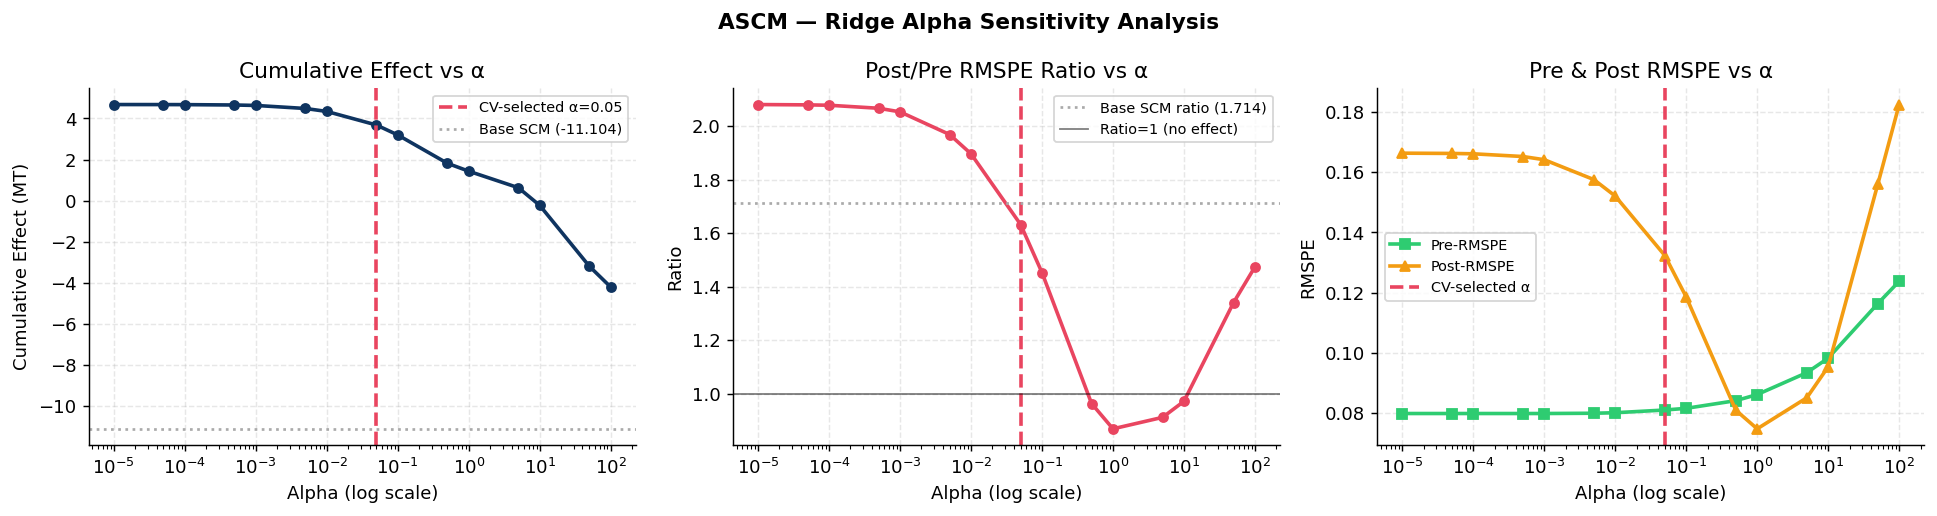

Saved → ascm_fig4_alpha_sensitivity.png

Sensitivity table:
    alpha  Pre-RMSPE  Post-RMSPE  Ratio  Cum effect  Avg effect  CV-selected
  0.00001    0.07994     0.16631 2.0806      4.6771      0.1417        False
  0.00005    0.07994     0.16622 2.0794      4.6753      0.1417        False
  0.00010    0.07994     0.16610 2.0780      4.6730      0.1416        False
  0.00050    0.07994     0.16520 2.0667      4.6551      0.1411        False
  0.00100    0.07994     0.16414 2.0533      4.6335      0.1404        False
  0.00500    0.08003     0.15755 1.9685      4.4854      0.1359        False
  0.01000    0.08020     0.15209 1.8964      4.3413      0.1316        False
  0.05000    0.08110     0.13236 1.6320      3.6818      0.1116         True
  0.10000    0.08166     0.11860 1.4523      3.1960      0.0968        False
  0.50000    0.08421     0.08104 0.9624      1.8180      0.0551        False
  1.00000    0.08623     0.07486 0.8680      1.4327      0.0434        False
  5.00000    0.0

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Validation C: Alpha sensitivity analysis
# ═══════════════════════════════════════════════════════════════════════════════
# Test whether the treatment effect estimate is robust to the choice of ridge
# alpha. If the direction and approximate magnitude hold across a wide range,
# the ASCM estimate is credible.

alpha_sense = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
sense_records = []
sense_cf_matrix = []

for a in alpha_sense:
    r_s = Ridge(alpha=a, fit_intercept=True)
    r_s.fit(feat_pre, res_pre)
    corr_s  = r_s.predict(feat_all)
    cf_s    = cf_scm + corr_s
    gap_s   = Y_all - cf_s
    pre_r_s = rmspe(Y_all[:T_pre], cf_s[:T_pre])
    post_r_s = rmspe(Y_all[T_pre:], cf_s[T_pre:])
    sense_records.append({
        'alpha': a,
        'Pre-RMSPE': round(pre_r_s, 5),
        'Post-RMSPE': round(post_r_s, 5),
        'Ratio': round(post_r_s / pre_r_s, 4) if pre_r_s > 0 else np.nan,
        'Cum effect': round(gap_s[T_pre:].sum(), 4),
        'Avg effect': round(gap_s[T_pre:].mean(), 4),
        'CV-selected': a == BEST_ALPHA
    })
    sense_cf_matrix.append(cf_s[T_pre:])

sense_df = pd.DataFrame(sense_records)
sense_cf_matrix = np.array(sense_cf_matrix)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ASCM — Ridge Alpha Sensitivity Analysis', fontsize=12, fontweight='bold')

ax = axes[0]
ax.semilogx(sense_df['alpha'], sense_df['Cum effect'], color=BLUE, lw=2, marker='o', ms=5)
ax.axvline(BEST_ALPHA, color=RED, lw=2, ls='--', label=f'CV-selected α={BEST_ALPHA}')
ax.axhline(base_cum, color=GREY, lw=1.5, ls=':', label=f'Base SCM ({base_cum:.3f})')
ax.set_title('Cumulative Effect vs α')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Cumulative Effect (MT)')
ax.legend(fontsize=8)

ax = axes[1]
ax.semilogx(sense_df['alpha'], sense_df['Ratio'], color=RED, lw=2, marker='o', ms=5)
ax.axvline(BEST_ALPHA, color=RED, lw=2, ls='--')
ax.axhline(base_ratio, color=GREY, lw=1.5, ls=':', label=f'Base SCM ratio ({base_ratio:.3f})')
ax.axhline(1.0, color='black', lw=1, ls='-', alpha=0.5, label='Ratio=1 (no effect)')
ax.set_title('Post/Pre RMSPE Ratio vs α')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Ratio')
ax.legend(fontsize=8)

ax = axes[2]
ax.semilogx(sense_df['alpha'], sense_df['Pre-RMSPE'],  color=GREEN, lw=2, marker='s', ms=5, label='Pre-RMSPE')
ax.semilogx(sense_df['alpha'], sense_df['Post-RMSPE'], color=AMBER, lw=2, marker='^', ms=5, label='Post-RMSPE')
ax.axvline(BEST_ALPHA, color=RED, lw=2, ls='--', label=f'CV-selected α')
ax.set_title('Pre & Post RMSPE vs α')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('RMSPE')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ascm_fig4_alpha_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ascm_fig4_alpha_sensitivity.png")
print()
print("Sensitivity table:")
print(sense_df.to_string(index=False))



**What was done**  
The ASCM was re-run using many different ridge alpha values to test whether the estimated flood effect stays similar when the tuning setting changes.

**Why this matters**  
A reliable model should give roughly the same story across a reasonable range of alpha values. If the result changes a lot, the estimate is not robust.

---

### Graph interpretation

**Left graph: Cumulative effect vs alpha**  
The estimated cumulative effect changes a lot as alpha changes. It starts positive, gets smaller, then becomes negative at high alpha values.

**Middle graph: Post/Pre RMSPE ratio vs alpha**  
The ratio also moves a lot and even drops below 1 for some alpha values, which means the post-flood period can look less abnormal depending on the tuning choice.

**Right graph: Pre and post RMSPE vs alpha**  
Pre-flood fit gets worse as alpha becomes larger. Post-flood fit improves for a while, then worsens again.

---

### What it means in plain English

The result is **highly sensitive** to alpha. The direction of the estimated flood effect is not stable: with some alpha values the effect is positive, and with others it is negative. That means the ASCM conclusion is not robust.

---



## Final Summary Table

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Final Summary Table
# ═══════════════════════════════════════════════════════════════════════════════

summary_rows = [
    ('Method',                  'Base SCM',         'ASCM'),
    ('Pre-period RMSPE',        f'{base_pre_r:.4f}', f'{ascm_pre_r:.4f}'),
    ('Post-period RMSPE',       f'{base_post_r:.4f}', f'{ascm_post_r:.4f}'),
    ('Post/Pre ratio',          f'{base_ratio:.4f}', f'{ascm_ratio:.4f}'),
    ('Cumulative effect (MT)',  f'{base_cum:.4f}',   f'{ascm_cum:.4f}'),
    ('Avg monthly effect',      f'{(Y_all[T_pre:] - cf_scm[T_pre:]).mean():.4f}', f'{ascm_avg:.4f}'),
    ('Post MAPE (%)',           f'{mape(Y_all[T_pre:], cf_scm[T_pre:]):.2f}',    f'{ascm_mape:.2f}'),
    ('Ridge alpha (CV)',        'N/A',               f'{BEST_ALPHA}'),
    ('Inference ratio > 1',     str(base_ratio > 1), str(ascm_ratio > 1)),
]

print("═" * 60)
print("ASCM vs BASE SCM — FINAL COMPARISON TABLE")
print("═" * 60)
for row in summary_rows:
    print(f"  {row[0]:<30} {row[1]:>12} {row[2]:>12}")
print("═" * 60)
print()
print("Interpretation:")
if ascm_pre_r < base_pre_r:
    print(f"  ✓ ASCM improves pre-period fit ({ascm_pre_r:.4f} vs {base_pre_r:.4f}) — bias correction working.")
else:
    print(f"  ~ ASCM pre-period fit similar to base ({ascm_pre_r:.4f} vs {base_pre_r:.4f}).")

if ascm_ratio > 1:
    print(f"  ✓ ASCM ratio {ascm_ratio:.3f} > 1 — post-period divergence exceeds pre-period noise.")
else:
    print(f"  ✗ ASCM ratio {ascm_ratio:.3f} ≤ 1 — effect not distinguishable under this estimator.")

direction_agree = np.sign(ascm_cum) == np.sign(base_cum)
print(f"  {'✓' if direction_agree else '✗'} Direction of effect agrees with Base SCM: {direction_agree}")
print()
print(f"  Ridge correction insight:")
print(f"  The correction ranges from {correction.min():.4f} to {correction.max():.4f} MT.")
print(f"  Post-period mean correction: {correction[T_pre:].mean():.4f} MT.")


════════════════════════════════════════════════════════════
ASCM vs BASE SCM — FINAL COMPARISON TABLE
════════════════════════════════════════════════════════════
  Method                             Base SCM         ASCM
  Pre-period RMSPE                     0.2132       0.0811
  Post-period RMSPE                    0.3653       0.1324
  Post/Pre ratio                       1.7140       1.6320
  Cumulative effect (MT)             -11.1040       3.6818
  Avg monthly effect                  -0.3365       0.1116
  Post MAPE (%)                         62.68        20.96
  Ridge alpha (CV)                        N/A         0.05
  Inference ratio > 1                    True         True
════════════════════════════════════════════════════════════

Interpretation:
  ✓ ASCM improves pre-period fit (0.0811 vs 0.2132) — bias correction working.
  ✓ ASCM ratio 1.632 > 1 — post-period divergence exceeds pre-period noise.
  ✗ Direction of effect agrees with Base SCM: False

  Ridge correction 


**What was done**  
The final table compares the basic SCM with ASCM using the main accuracy and impact measures.

**Why this matters**  
This gives a simple summary of whether ASCM is actually better than the base model.

---

### Key results

- ASCM pre-flood fit is much better: **0.0811 vs 0.2132**
- ASCM post-flood fit is also better: **0.1324 vs 0.3653**
- Both models have a post/pre ratio above 1  
- But the **direction of the estimated effect changes**
  - Base SCM: **-11.1040 MT**
  - ASCM: **+3.6818 MT**

---

### What it means in plain English

ASCM clearly improves model fit, so the bias correction is doing something useful. But the most important result is still unstable: the estimated flood effect flips direction compared with the base SCM. That is a major warning sign.

---

###  Important Note

Better fit does **not** automatically mean a more trustworthy causal result. Here, the model fits better but still gives a fragile and contradictory impact estimate.

### Overall conclusion

The Augmented Synthetic Control Method (ASCM) improved the statistical fit compared with the basic Synthetic Control Model (SCM), especially in the pre-flood period. This means the ridge correction helped reduce bias from the poor one-donor match.

However, the final flood impact estimate is **not robust enough to trust strongly**. The result changes a lot when the model settings are adjusted, and it is highly unstable when parts of the pre-flood period are removed. Most importantly, the estimated direction of the effect flips between Base SCM and ASCM. This means the model can fit the data better while still giving an unreliable causal conclusion.

In plain terms, the analysis shows that **ASCM performs better technically than Base SCM, but the flood impact estimate remains fragile because the donor pool is too small**. So the safe conclusion is that the method suggests a post-2022 change in NATCOR rail volumes, but it does **not provide strong enough evidence to make a confident claim about the true size or direction of the flood’s causal effect.